In [1]:
import pandas as pd

data_2023_2024=pd.read_html("https://fbref.com/es/comps/9/horario/Resultados-y-partidos-en-Premier-League", encoding = 'UTF-8')
data = pd.read_htmldata_2022_2023=pd.read_html("https://fbref.com/es/comps/9/2022-2023/horario/Marcadores-y-partidos-de-2022-2023-Premier-League", encoding = 'UTF-8')

data = data[0]
data_2023_2024 = data_2023_2024[0]

#unir dataframes
df = [data,data_2023_2024]
df = pd.concat(df)

#agregar columnas de goles locales y goles visita
df[['Goles Local','Goles Visita']] = df['Marcador'].str.split('–', expand=True)
#Eliminar la columna de Marcador
data = df.drop('Marcador', axis=1)


import re
def extraer_numero(cadena):
    numeros = re.findall(r'\b\d+\b', str(cadena))
    if numeros:
        return int(numeros[0])
    else:
        return None
    
data['Goles Local'] = data['Goles Local'].apply(extraer_numero).fillna(0).astype(int)
data['Goles Visita'] = data['Goles Visita'].apply(extraer_numero).fillna(0).astype(int)
indices_a_eliminar = [indice for indice, valor in data['Sem.'].iteritems() if pd.isna(valor)]
data = data.drop(indices_a_eliminar)
data = data.reset_index(drop=True)

data

AttributeError: 'Series' object has no attribute 'iteritems'

In [8]:
import pandas as pd
data_2023_2024=pd.read_html("https://fbref.com/es/comps/9/horario/Resultados-y-partidos-en-Premier-League", encoding = 'UTF-8')
data = pd.read_htmldata_2022_2023=pd.read_html("https://fbref.com/es/comps/9/2022-2023/horario/Marcadores-y-partidos-de-2022-2023-Premier-League", encoding = 'UTF-8')
data = data[0]

In [9]:

# Inicializa el contador j
j = 0

# Recorre los datos para contar cuántas veces aparece 'Marcador'
for i in range(len(data)):
    if data.loc[i, 'Marcador'] == 'Marcador':
        print(i)
        j = j + 1

# Limpieza de la columna 'Marcador'
data['Marcador'] = data['Marcador'].str.replace('–', '-', regex=False)  # Reemplaza guiones
data['Marcador'] = data['Marcador'].str.replace(r'\(\d\)', '', regex=True).str.strip()  # Limpia caracteres no deseados
data['Marcador'] = data['Marcador'].fillna('0-0')  # Rellena valores nulos con '0-0'

# Corrige el valor en la fila `j` si fuera necesario
if j < len(data):
    data.loc[j, 'Marcador'] = '0-0'

# Divide la columna 'Marcador' en 'Gol_local' y 'Gol_visita'
data[['Gol Local', 'Gol Visita']] = data['Marcador'].str.split('-', expand=True).astype(int)

# Elimina la columna 'Marcador'
data.drop(['Marcador'], axis=1, inplace=True)

# Si j es un índice válido, elimina la fila `j`
if j < len(data):
    data = data.drop(j)

data


,Sem.,Día,Fecha,Hora,Local,xG,xG.1,Visitante,Asistencia,Sedes,Árbitro,Informe del partido,Notas,Gol Local,Gol Visita
1,1.0,Sáb,2022-08-06,12:30,Fulham,1.2,1.2,Liverpool,22207.0,Craven Cottage,Andy Madley,Informe del partido,NaN,2,2
2,1.0,Sáb,2022-08-06,15:00,Tottenham,1.5,0.5,Southampton,61732.0,Tottenham Hotspur Stadium,Andre Marriner,Informe del partido,NaN,4,1
3,1.0,Sáb,2022-08-06,15:00,Newcastle Utd,1.7,0.3,Nott'ham Forest,52245.0,St James' Park,Simon Hooper,Informe del partido,NaN,2,0
4,1.0,Sáb,2022-08-06,15:00,Leeds United,0.8,1.3,Wolves,36347.0,Elland Road,Robert Jones,Informe del partido,NaN,2,1
5,1.0,Sáb,2022-08-06,15:00,Bournemouth,0.6,0.7,Aston Villa,11013.0,Vitality Stadium,Peter Bankes,Informe del partido,NaN,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
425,38.0,Dom,2023-05-28,16:30,Everton,1.0,0.5,Bournemouth,39201.0,Goodison Park,Stuart Attwell,Informe del partido,NaN,1,0
426,38.0,Dom,2023-05-28,16:30,Leicester City,1.4,1.4,West Ham,32183.0,King Power Stadium,Simon Hooper,Informe del partido,NaN,2,1
427,38.0,Dom,2023-05-28,16:30,Aston Villa,2.8,1.4,Brighton,NaN,Villa Park,David Coote,Informe del partido,NaN,2,1
428,38.0,Dom,2023-05-28,16:30,Leeds United,1.5,2.2,Tottenham,36871.0,Elland Road,Anthony Taylor,Informe del partido,NaN,1,4


In [12]:
data_clean(data)

,Sem.,Día,Fecha,Hora,Local,xG,xG.1,Visitante,Asistencia,Sedes,Árbitro,Informe del partido,Notas,Gol Local,Gol Visita
1,1.0,Sáb,2022-08-06,12:30,Fulham,1.2,1.2,Liverpool,22207.0,Craven Cottage,Andy Madley,Informe del partido,NaN,2,2
2,1.0,Sáb,2022-08-06,15:00,Tottenham,1.5,0.5,Southampton,61732.0,Tottenham Hotspur Stadium,Andre Marriner,Informe del partido,NaN,4,1
3,1.0,Sáb,2022-08-06,15:00,Newcastle Utd,1.7,0.3,Nott'ham Forest,52245.0,St James' Park,Simon Hooper,Informe del partido,NaN,2,0
4,1.0,Sáb,2022-08-06,15:00,Leeds United,0.8,1.3,Wolves,36347.0,Elland Road,Robert Jones,Informe del partido,NaN,2,1
5,1.0,Sáb,2022-08-06,15:00,Bournemouth,0.6,0.7,Aston Villa,11013.0,Vitality Stadium,Peter Bankes,Informe del partido,NaN,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
425,38.0,Dom,2023-05-28,16:30,Everton,1.0,0.5,Bournemouth,39201.0,Goodison Park,Stuart Attwell,Informe del partido,NaN,1,0
426,38.0,Dom,2023-05-28,16:30,Leicester City,1.4,1.4,West Ham,32183.0,King Power Stadium,Simon Hooper,Informe del partido,NaN,2,1
427,38.0,Dom,2023-05-28,16:30,Aston Villa,2.8,1.4,Brighton,NaN,Villa Park,David Coote,Informe del partido,NaN,2,1
428,38.0,Dom,2023-05-28,16:30,Leeds United,1.5,2.2,Tottenham,36871.0,Elland Road,Anthony Taylor,Informe del partido,NaN,1,4


In [59]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
# Asegúrate de que la columna 'Sem.' sea de tipo string
data['Sem.'] = data['Sem.'].astype(str)

# Crear una nueva columna de "Gol Total" que suma las columnas de goles local y visita
data['Gol Total'] = data[['Gol Local', 'Gol Visita']].sum(axis=1)

# Agrupar por la columna de semana y sumar los goles totales por semana
goles_por_semana = data.groupby('Sem.')['Gol Total'].sum().reset_index()

goles_por_semana = goles_por_semana.drop(index=38)
goles_por_semana['Sem.'] = goles_por_semana['Sem.'].str.extract('(\d+)').astype(str)


# Mostrar el DataFrame resultante
print(goles_por_semana)

   Sem.  Gol Total
0     1         26
1    10         34
2    11         15
3    12         17
4    13         30
5    14         27
6    15         37
7    16         29
8    17         34
9    18         23
10   19         25
11    2         28
12   20         21
13   21         18
14   22         21
15   23         26
16   24         21
17   25         23
18   26         31
19   27         23
20   28         34
21   29         31
22    3         32
23   30         28
24   31         36
25   32         37
26   33         29
27   34         44
28   35         34
29   36         28
30   37         23
31   38         33
32    4         30
33    5         25
34    6         32
35    7         33
36    8         28
37    9         36


In [61]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler

goles_por_semana.sort_values(by='Gol Total', ascending=True,)

scaler = MinMaxScaler()
goles_por_semana['Gol Total Normalizado'] = scaler.fit_transform(goles_por_semana[['Gol Total']])

scaler1 = StandardScaler()
goles_por_semana['Gol Total Estandarizado'] = scaler1.fit_transform(goles_por_semana[['Gol Total']])


scaler2 = MaxAbsScaler()
goles_por_semana['Gol Total MaxAbs Normalizado'] = scaler2.fit_transform(goles_por_semana[['Gol Total']])

print(goles_por_semana)

   Sem.  Gol Total  Gol Total Normalizado  Gol Total Estandarizado  \
0     1         26               0.379310                -0.399700   
1    10         34               0.655172                 0.892946   
2    11         15               0.000000                -2.177088   
3    12         17               0.068966                -1.853926   
4    13         30               0.517241                 0.246623   
5    14         27               0.413793                -0.238119   
6    15         37               0.758621                 1.377688   
7    16         29               0.482759                 0.085042   
8    17         34               0.655172                 0.892946   
9    18         23               0.275862                -0.884442   
10   19         25               0.344828                -0.561280   
11    2         28               0.448276                -0.076538   
12   20         21               0.206897                -1.207603   
13   21         18  

In [69]:
goles_por_semana['Sem.'] = goles_por_semana['Sem.'].str.extract('(\d+)').astype(int)
goles_por_semana[['Sem.','Gol Total']].sort_values(by='Sem.', ascending=True)

,Sem.,Gol Total
0,1,26
11,2,28
22,3,32
32,4,30
33,5,25
34,6,32
35,7,33
36,8,28
37,9,36
1,10,34


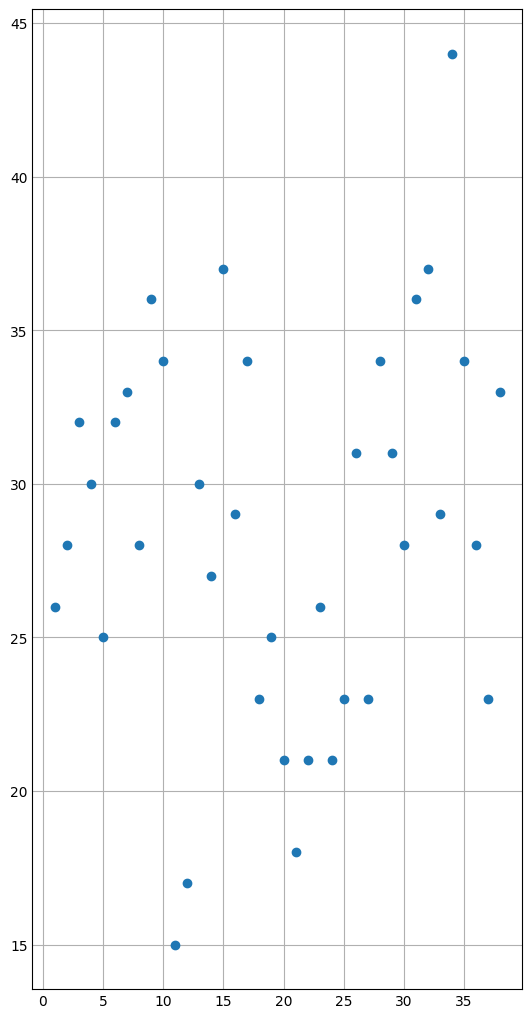

In [85]:
import matplotlib.pyplot as plt



# plot
fig, ax = plt.subplots(figsize=(5,10))

ax.plot(goles_por_semana['Sem.'], goles_por_semana['Gol Total'] , 'o')


Text(0, 0.5, 'Goles por Semana')

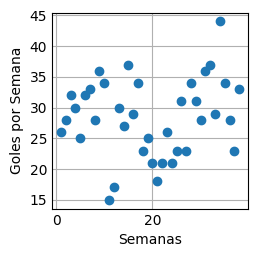

In [84]:
plt.plot(goles_por_semana['Sem.'], goles_por_semana['Gol Total'],'o')
plt.xlabel('Semanas')
plt.ylabel('Goles por Semana')

In [15]:
data['Gol Total'].head(9).sum

26

# data.iloc[[id da la fila],[id de la columna]]

In [26]:
data.iloc[[1,5,8,36],[2,5,7]]

,Fecha,xG,Visitante
1,2022-08-06,1.2,Liverpool
5,2022-08-06,0.6,Aston Villa
8,2022-08-07,1.4,Brighton
36,2022-08-27,1.8,Leicester City


ConversionError: Failed to convert value(s) to axis units: array(['Sáb', 'Sáb', 'Sáb', 'Sáb', 'Sáb', 'Sáb', 'Dom', 'Dom', 'Dom', nan,
       'Sáb', 'Sáb', 'Sáb', 'Sáb', 'Sáb', 'Sáb', 'Sáb', 'Dom', 'Dom',
       'Lun', nan, 'Sáb', 'Sáb', 'Sáb', 'Sáb', 'Sáb', 'Sáb', 'Dom', 'Dom',
       'Dom', 'Lun', nan, 'Sáb', 'Sáb', 'Sáb', 'Sáb', 'Sáb', 'Sáb', 'Sáb',
       'Dom', 'Dom', 'Dom', nan, 'Mar', 'Mar', 'Mar', 'Mar', 'Mié', 'Mié',
       'Mié', 'Mié', 'Mié', 'Jue', nan, 'Sáb', 'Sáb', 'Sáb', 'Sáb', 'Sáb',
       'Sáb', 'Sáb', 'Sáb', 'Dom', 'Dom', nan, 'Vie', 'Vie', 'Sáb', 'Sáb',
       'Sáb', 'Dom', 'Dom', nan, 'Sáb', 'Sáb', 'Sáb', 'Sáb', 'Sáb', 'Sáb',
       'Sáb', 'Dom', 'Dom', 'Lun', nan, 'Sáb', 'Sáb', 'Sáb', 'Sáb', 'Sáb',
       'Dom', 'Dom', 'Dom', 'Dom', 'Lun', nan, 'Vie', 'Sáb', 'Sáb', 'Sáb',
       'Sáb', 'Dom', 'Dom', 'Dom', 'Dom', 'Dom', nan, 'Mar', 'Mar', 'Mié',
       'Mié', 'Mié', 'Mié', 'Mié', 'Jue', 'Jue', nan, 'Sáb', 'Sáb', 'Sáb',
       'Sáb', 'Dom', 'Dom', 'Dom', 'Dom', 'Dom

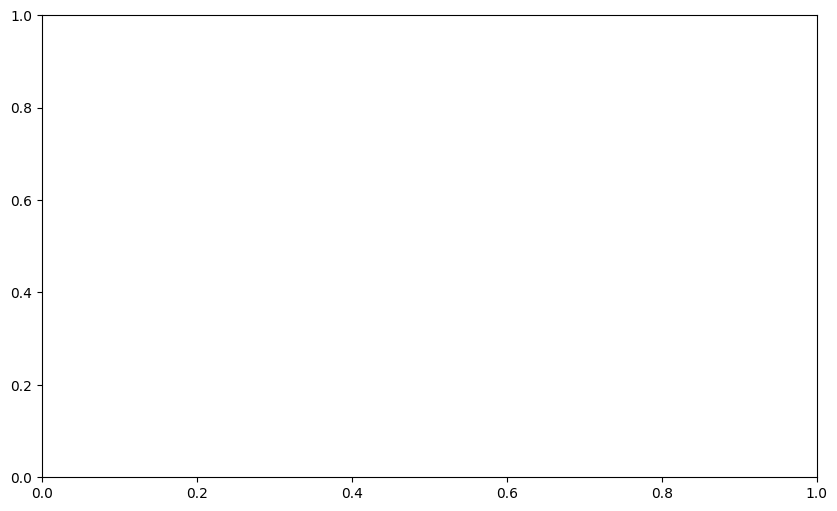

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Cargar los datos
data = data['Gol Local'] + data['Gol Visita']

# 2. Visualizar la serie de tiempo
plt.figure(figsize=(10, 6))
plt.plot(data, )
plt.title("Serie de Tiempo de Goles por Semana")
plt.xlabel("Fecha")
plt.ylabel("Goles")
plt.legend()
plt.show()

# 3. Hacer la serie estacionaria (si es necesario)
# Realizamos la diferenciación de la serie
data_diff = data.diff().dropna()

# Verificamos con gráficas ACF y PACF
plot_acf(data_diff, lags=20)
plt.show()
plot_pacf(data_diff, lags=20)
plt.show()

# 4. Ajuste del Modelo ARIMA - Seleccionamos p, d, q basado en ACF y PACF
# En este caso, el modelo ARIMA(1, 1, 1) es un ejemplo, pero puede variar según los datos
model = ARIMA(data, order=(1, 1, 1))
model_fit = model.fit()

# 5. Resumen del modelo
print(model_fit.summary())

# 6. Evaluación del modelo
# Realizar predicciones y calcular el RMSE en el set de entrenamiento
data_pred = model_fit.predict(start=1, end=len(data), typ='levels')
rmse = np.sqrt(mean_squared_error(data[1:], data_pred[1:]))
print(f"RMSE del modelo: {rmse}")

# 7. Predicciones a futuro
# Predicciones de los próximos 4 periodos (semanas, en este caso)
forecast = model_fit.forecast(steps=4)
print("Pronóstico de goles para las próximas 4 semanas:")
print(forecast)
